**ODE :**

In [26]:
import numpy as np

In [27]:
import numpy as np

def fun(X):
    return np.array([np.sin(X[1]), np.cos(X[0])])


X0 = np.array([0.0, 0.0])  # Initial position
V0 = np.array([0.0, 0.0])  # Initial velocity
t0 = 0
tf = 50
N = 50
dt = (tf - t0) / N

Xold = X0 + V0 * dt + (fun(X0) * dt**2) / 2


for i in range(N):
    Xnew = -Xold + 2 * X0 + dt**2 * fun(X0)
    Xold = X0
    X0 = Xnew

print("Final position:", X0)


Final position: [-230.68691846   43.77541187]


In [28]:
import matplotlib.pyplot as plt

array([-149.116263  ,  173.84013393])

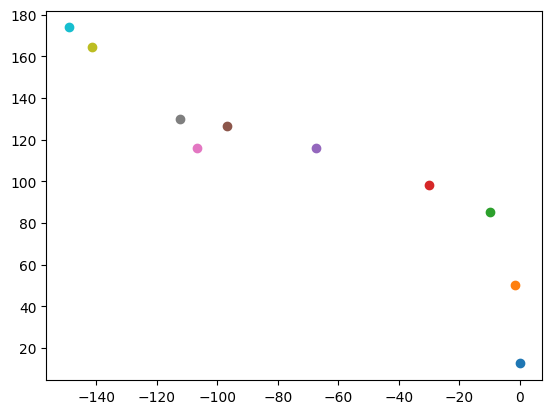

In [29]:
def fun(X):
    return  np.array([np.sin(X[1]) ,np.cos(X[0])])
X0=np.array([0.0,0.0])
t0=0
tf=50
N=10
V0=np.array([0.0,0.0])
dt=(tf-t0)/N

Xold= X0 + V0 *dt + (fun(X0) * dt**2)/2
for i in range( N):
    Xnew= - Xold +2*X0 + dt**2 * fun(X0)
    
    Xold=X0
    X0=Xnew
    plt.scatter(X0[0],X0[1])
X0

RK 2

In [30]:
def F(X):
    return np.array([np.sin(X[1]),np.cos(X[0])])

In [31]:
def f(X):
    return X

In [32]:
# X= x,y,vx,vy
def G(t,f):
    return np.array([f[2],f[3],np.sin(f[1]),np.cos(f[0])])

In [33]:
def df(t,f):
    return G(t,f)

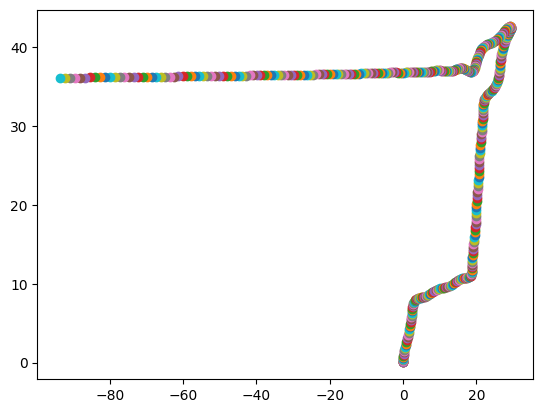

In [34]:
f=np.array([0,0,0,0])
t=0
tf=50
delta_t=1e-1
N=int(tf/delta_t)
for i in range (N):
    k1=delta_t*G(t,f)
    k2=delta_t*G(t,f +(k1/2))
    f=f +k2
    plt.scatter(f[0],f[1])
    
    

In [35]:
import numpy as np
import matplotlib.pyplot as plt
def p(X):
    return (np.sin(X))
def q(X):
    return 1 +0.0 * X
def s(X):
    return X*0

N=4
X=np.linspace(0,4*np.pi,N+2)
delta_x=X[1]-X[0]
S=np.zeros(N)
B=np.zeros(N)
B[0]= (1/(delta_x) -p(X)[1]/(2*delta_x)) * 0
B[N-1]=(1/(delta_x) -p(X)[1]/(2*delta_x))* 1

D=np.zeros((N,N))
D
for i in range(N):
    D[i][i]=q(X)[i] - 2/delta_x
    if(i<N-1):
        D[i,i+1]=(1/delta_x**2) +p(X)[i+1]/(2*delta_x)
    if(i>0):
        D[i,i-1]=(1/delta_x**2) -p(X)[i+1]/(2*delta_x)

    
D
Dinv=np.linalg.inv(D)
Dinv
F=np.matmul(Dinv, S-B)

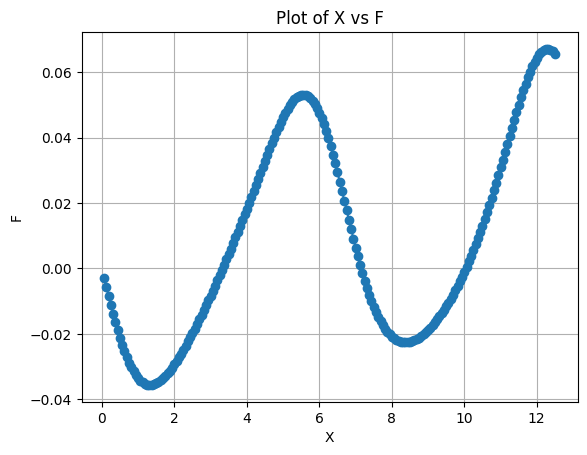

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Define functions
def p(X):
    return np.sin(X)

def q(X):
    return 1 + 0.0 * X

def s(X):
    return X * 0  # Always returns zero array

# Define parameters
N = 200
X = np.linspace(0, 4 * np.pi, N + 2)  # Discretized points
delta_x = X[1] - X[0]  # Step size

# Initialize arrays
S = np.zeros(N)
B = np.zeros(N)
D = np.zeros((N, N))

# Set boundary conditions
B[0] = (1 / delta_x - p(X[1]) / (2 * delta_x)) * 0
B[N - 1] = (1 / delta_x - p(X[N]) / (2 * delta_x)) * 1  

# Construct matrix D
for i in range(N):
    D[i, i] = q(X[i+1]) - 2 / (delta_x ** 2)  # Adjust indexing
    if i < N - 1:
        D[i, i+1] = (1 / delta_x ** 2) + p(X[i+1]) / (2 * delta_x)
    if i > 0:
        D[i, i-1] = (1 / delta_x ** 2) - p(X[i+1]) / (2 * delta_x)

# Solve system
Dinv = np.linalg.inv(D)
F = np.matmul(Dinv, S - B)

# Plot results
plt.plot(X[1:-1], F, marker='o', linestyle='-')
plt.xlabel("X")
plt.ylabel("F")
plt.title("Plot of X vs F")
plt.grid(True)
plt.show()
